In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("calories.csv")
df['BMI'] = df['Weight']/((df['Height']/100)**2)
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,BMI
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0,26.038781
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0,21.773842
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0,24.655910
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0,22.159109
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0,24.456063


In [2]:
#User_ID is not needed
df = df.drop(columns=['User_ID'])
#Now for gender
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
#male = 1, female = 0
df.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,BMI
0,1,68,190.0,94.0,29.0,105.0,40.8,231.0,26.038781
1,0,20,166.0,60.0,14.0,94.0,40.3,66.0,21.773842
2,1,69,179.0,79.0,5.0,88.0,38.7,26.0,24.655910
3,0,34,179.0,71.0,13.0,100.0,40.5,71.0,22.159109
4,0,27,154.0,58.0,10.0,81.0,39.8,35.0,24.456063


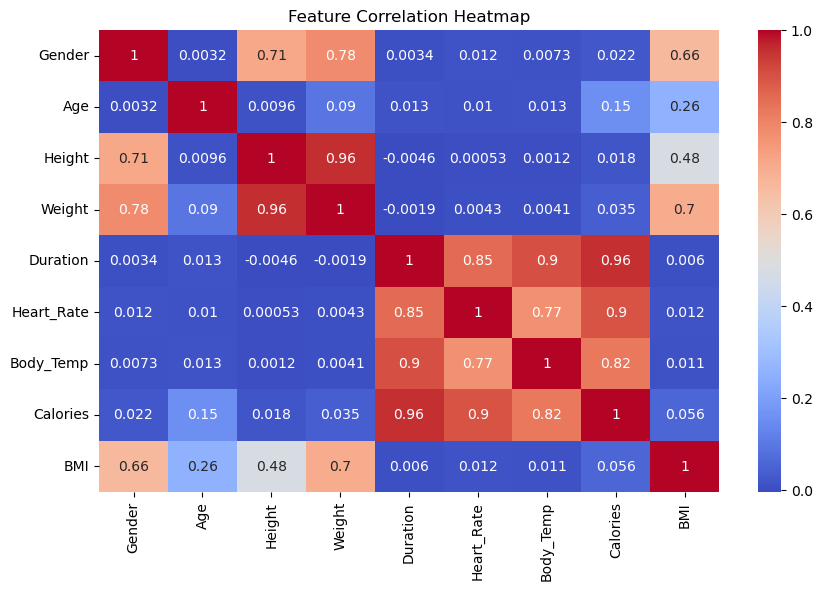

In [3]:
#Correlation HeatMap
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

#Splitting Data
from sklearn.model_selection import train_test_split
X = df.drop(['Calories'], axis=1)
y = df['Calories']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 51)

In [4]:
#Scaling the features so that all of them have an equal ground to act
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
#Metric_Evaluation Function for all the models
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def evaluate_model(y_test, preds):
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    mape = np.mean(np.abs((y_test - preds) / y_test)) * 100

    return rmse, mae, r2, mape
    
#Models that will be used
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
#Training of the models

#Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_rmse, lr_mae, lr_r2, lr_mape = evaluate_model(y_test, lr_preds)

#Decision Tree
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)
dt_rmse, dt_mae, dt_r2, dt_mape = evaluate_model(y_test, dt_preds)

#Random Forest
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_rmse, rf_mae, rf_r2, rf_mape = evaluate_model(y_test, rf_preds)

#XGBoost
xgb = XGBRegressor()
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
xgb_rmse, xgb_mae, xgb_r2, xgb_mape = evaluate_model(y_test, xgb_preds)

In [6]:
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "XGBoost"],
    "RMSE": [lr_rmse, dt_rmse, rf_rmse, xgb_rmse],
    "MAE": [lr_mae, dt_mae, rf_mae, xgb_mae],
    "R2": [lr_r2, dt_r2, rf_r2, xgb_r2],
    "MAPE (%)": [lr_mape, dt_mape, rf_mape, xgb_mape]
})
results_df

,Model,RMSE,MAE,R2,MAPE (%)
0,Linear Regression,11.107283,8.173635,0.967523,30.529607
1,Decision Tree,5.358420,3.451333,0.992442,4.928972
2,Random Forest,2.746803,1.739150,0.998014,2.797914
3,XGBoost,2.137998,1.474823,0.998797,2.783177


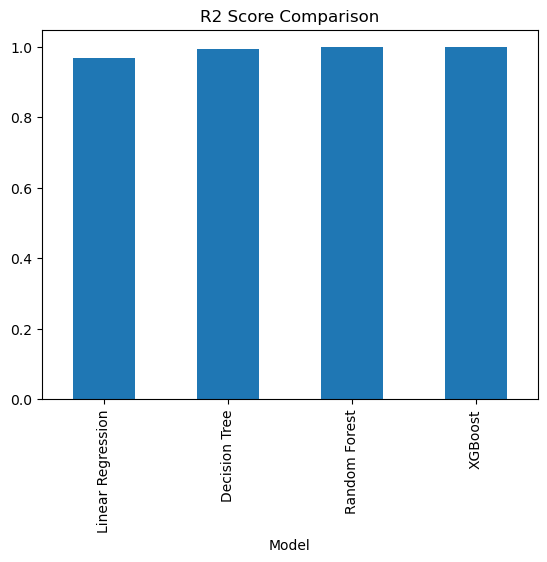

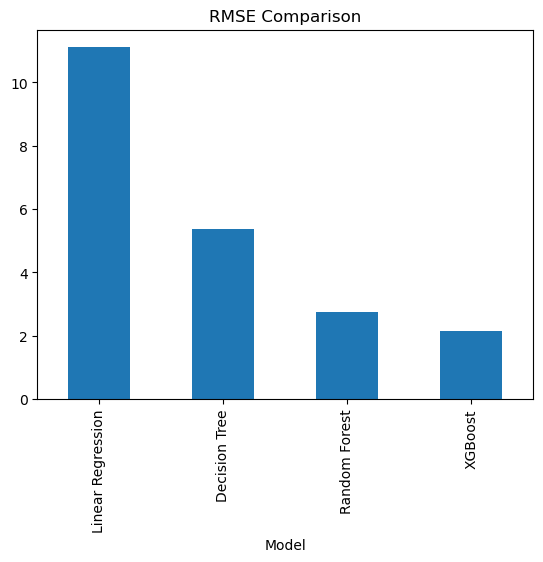

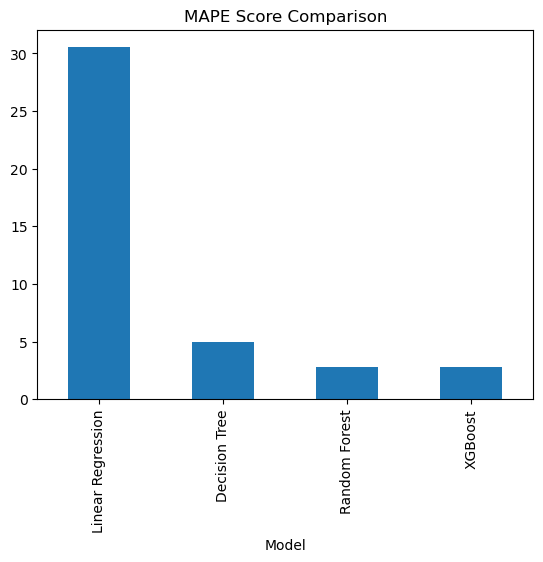

In [7]:
#Comparison PLots
results_df.set_index("Model")["R2"].plot(kind="bar", title="R2 Score Comparison")
plt.show()

results_df.set_index("Model")["RMSE"].plot(kind="bar", title="RMSE Comparison")
plt.show()

results_df.set_index("Model")["MAPE (%)"].plot(kind="bar", title="MAPE Score Comparison")
plt.show()

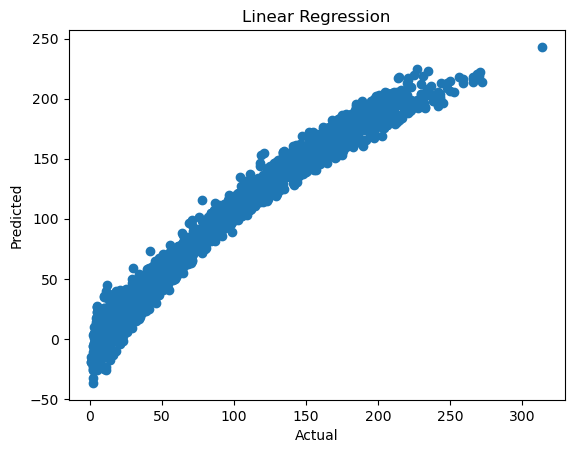

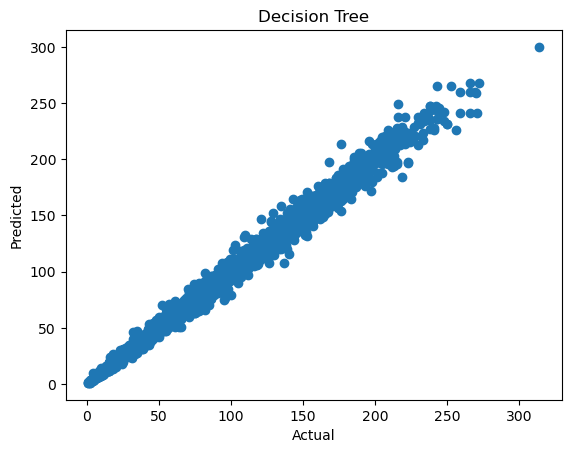

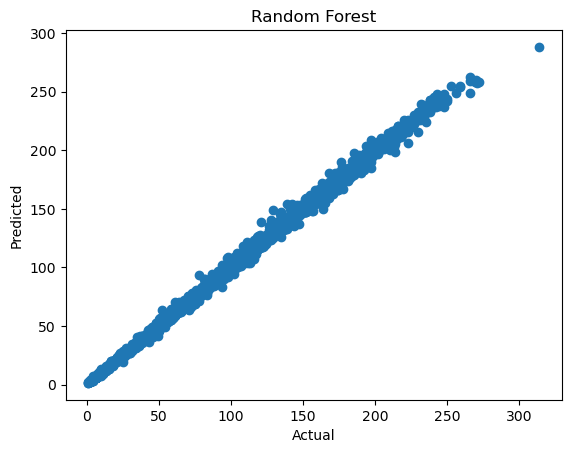

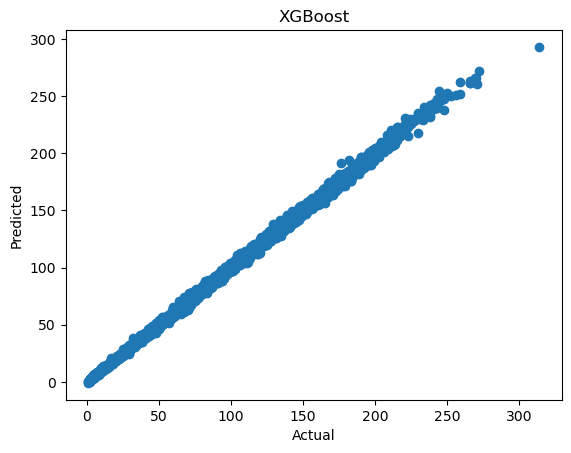

In [8]:
#Analysis of every model(Visualization)
plt.scatter(y_test, lr_preds)
plt.title("Linear Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.savefig("lr_plot.png")
plt.show()


plt.scatter(y_test, dt_preds)
plt.title("Decision Tree")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.savefig("dt_plot.png")
plt.show()


plt.scatter(y_test, rf_preds)
plt.title("Random Forest")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.savefig("rf_plot.png")
plt.show()


plt.scatter(y_test, xgb_preds)
plt.title("XGBoost")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.savefig("xgb_plot.png")
plt.show()

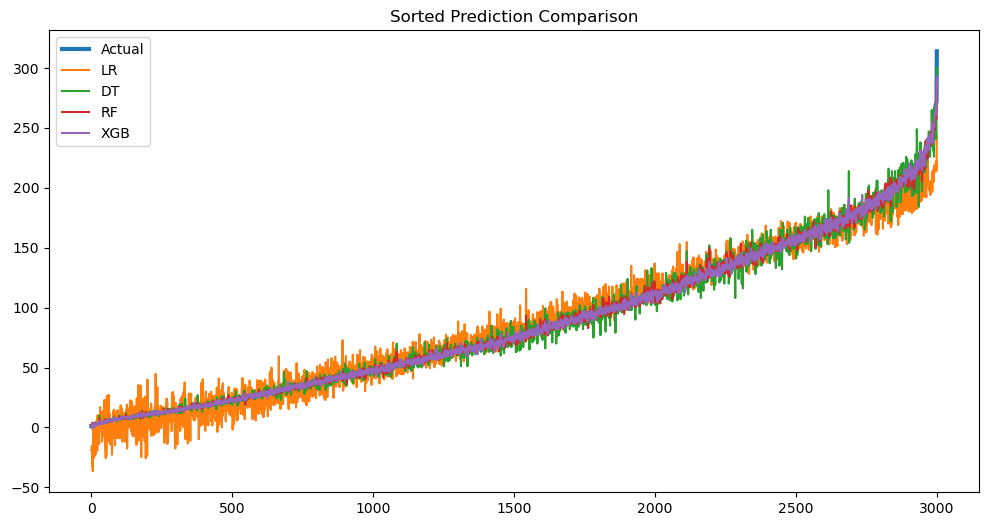

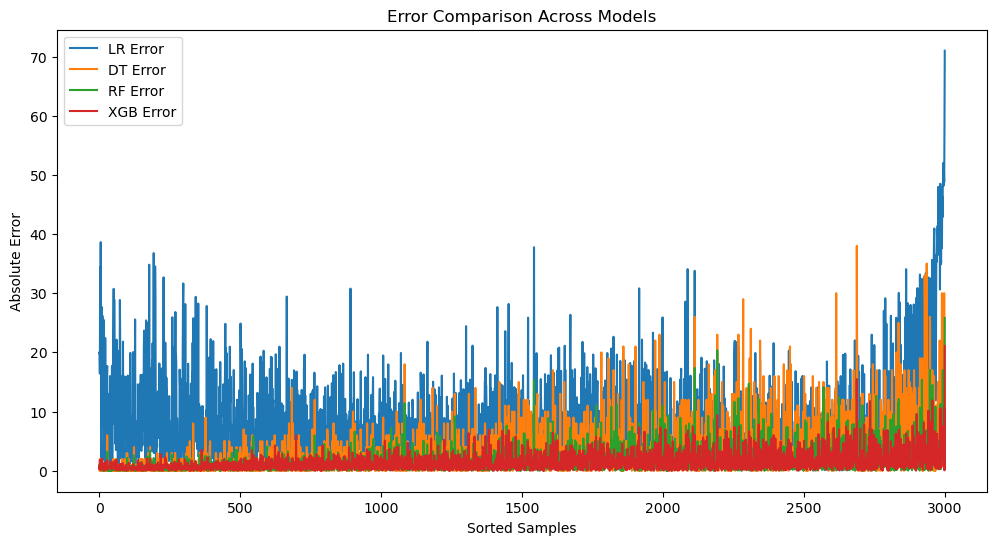

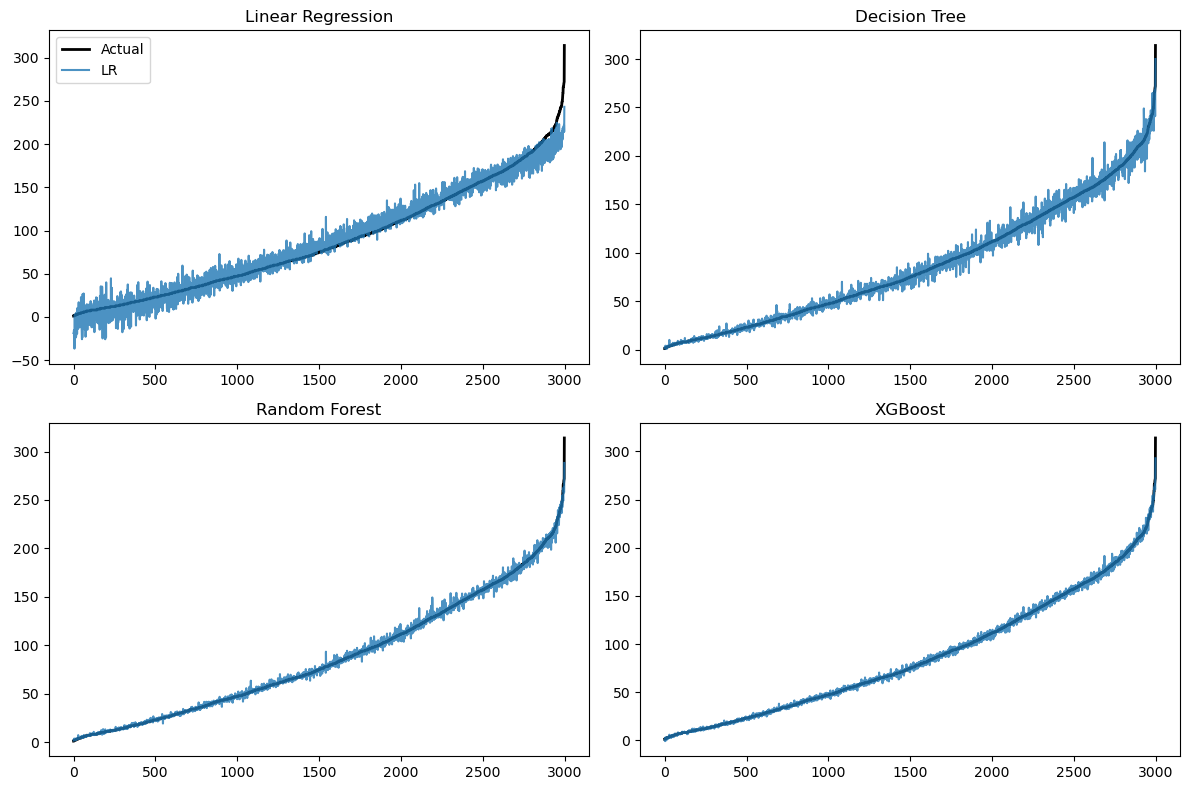

In [9]:
#Comparison between Model Prediction
sorted_idx = np.argsort(y_test.values)

y_sorted = y_test.values[sorted_idx]

lr_sorted = lr_preds[sorted_idx]
dt_sorted = dt_preds[sorted_idx]
rf_sorted = rf_preds[sorted_idx]
xgb_sorted = xgb_preds[sorted_idx]

plt.figure(figsize=(12,6))
plt.plot(y_sorted, label="Actual", linewidth=3)
plt.plot(lr_sorted, label="LR")
plt.plot(dt_sorted, label="DT")
plt.plot(rf_sorted, label="RF")
plt.plot(xgb_sorted, label="XGB")
plt.legend()
plt.title("Sorted Prediction Comparison")
plt.show()

#Error-Comparison
plt.figure(figsize=(12,6))
plt.plot(abs(y_sorted - lr_sorted), label="LR Error")
plt.plot(abs(y_sorted - dt_sorted), label="DT Error")
plt.plot(abs(y_sorted - rf_sorted), label="RF Error")
plt.plot(abs(y_sorted - xgb_sorted), label="XGB Error")
plt.legend()
plt.title("Error Comparison Across Models")
plt.xlabel("Sorted Samples")
plt.ylabel("Absolute Error")
plt.show()

#Subplots for side-by-side comparison
fig, axs = plt.subplots(2, 2, figsize=(12,8))

# Linear Regression
axs[0,0].plot(y_sorted, label="Actual", color="black", linewidth=2)
axs[0,0].plot(lr_sorted, label="LR", alpha=0.8)
axs[0,0].set_title("Linear Regression")
axs[0,0].legend()

# Decision Tree
axs[0,1].plot(y_sorted, color="black", linewidth=2)
axs[0,1].plot(dt_sorted, alpha=0.8)
axs[0,1].set_title("Decision Tree")

# Random Forest
axs[1,0].plot(y_sorted, color="black", linewidth=2)
axs[1,0].plot(rf_sorted, alpha=0.8)
axs[1,0].set_title("Random Forest")

# XGBoost
axs[1,1].plot(y_sorted, color="black", linewidth=2)
axs[1,1].plot(xgb_sorted, alpha=0.8)
axs[1,1].set_title("XGBoost")

plt.tight_layout()
plt.show()

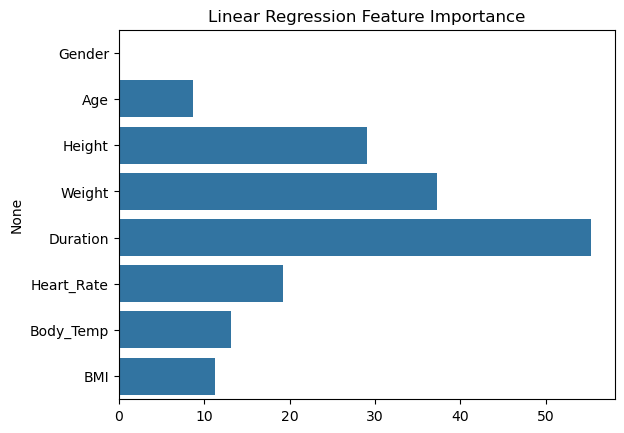

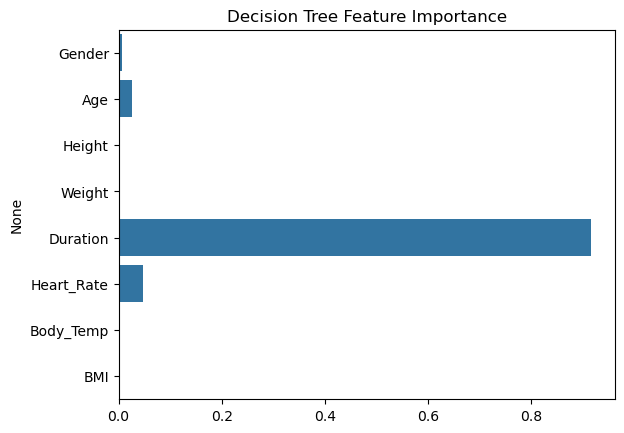

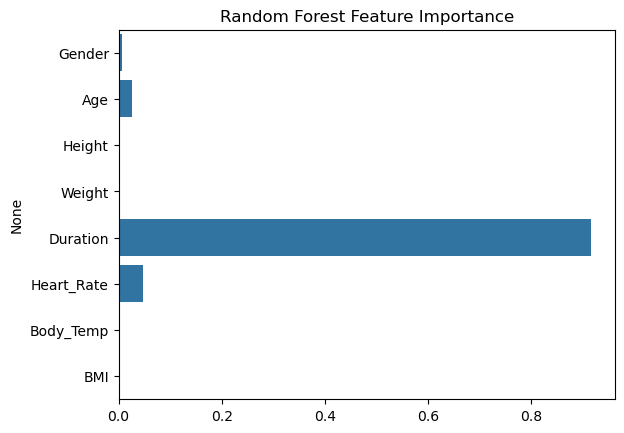

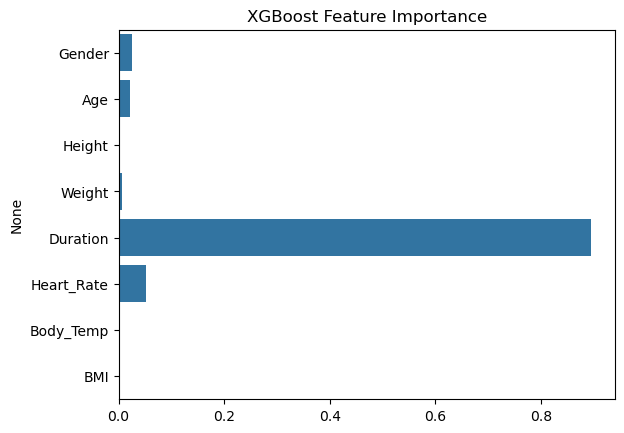

In [10]:
#Feature Information for every model
features = X.columns
#LR
lr_imp = np.abs(lr.coef_)
sns.barplot(x=lr_imp, y=features)
plt.title("Linear Regression Feature Importance")
plt.savefig("lr_feature.png")
plt.show()

#DT
dt_imp = dt.feature_importances_
sns.barplot(x=dt_imp, y=features)
plt.title("Decision Tree Feature Importance")
plt.savefig("dt_feature.png")
plt.show()

#RF
rf_imp = rf.feature_importances_
sns.barplot(x=rf_imp, y=features)
plt.title("Random Forest Feature Importance")
plt.savefig("rf_feature.png")
plt.show()

#XGB
xgb_imp = xgb.feature_importances_
sns.barplot(x=xgb_imp, y=features)
plt.title("XGBoost Feature Importance")
plt.savefig("xgb_feature.png")
plt.show()

In [11]:
#Choosing the best model for hosting
best_model = results_df.sort_values(by="R2", ascending=False).iloc[0]
best_model

Model        XGBoost
RMSE        2.137998
MAE         1.474823
R2          0.998797
MAPE (%)    2.783177
Name: 3, dtype: object

In [12]:
import pickle

pickle.dump(lr, open("lr.pkl", "wb"))
pickle.dump(dt, open("dt.pkl", "wb"))
pickle.dump(rf, open("rf.pkl", "wb"))
pickle.dump(xgb, open("xgb.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

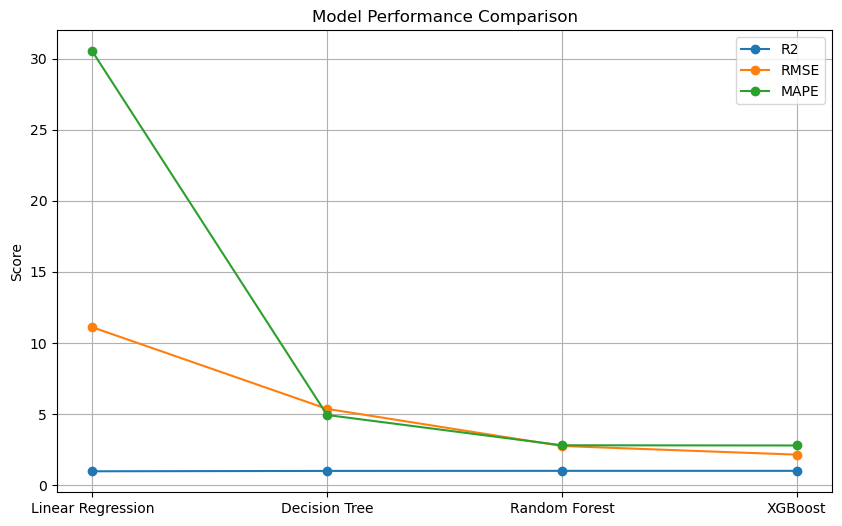

In [13]:
plt.figure(figsize=(10,6))
plt.plot(results_df["Model"], results_df["R2"], marker='o', label="R2")
plt.plot(results_df["Model"], results_df["RMSE"], marker='o', label="RMSE")
plt.plot(results_df["Model"], results_df["MAPE (%)"], marker='o', label="MAPE")
plt.legend()
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.grid()
plt.savefig("comparison.png")
plt.show()

In [14]:
results_df.to_csv("results.csv", index=False)